In [3]:
import os
import sys
import torch

# 1. Entrar o clonar/actualizar el repositorio en Colab
repo_dir = "/content/6g-phy-autoencoder"

if not os.path.exists(repo_dir):
  !git clone https://github.com/ismaelsanchezherrera/6g-phy-autoencoder.git
  os.chdir(repo_dir)
else:
  os.chdir(repo_dir)
  !git pull origin main

# 2. Añadir el directorio del repositorio al path de Python
sys.path.append(os.getcwd())

# 3. Importar módulos de tu proyecto
from src.evaluate import (
    evaluate_ber,
    plot_ber_curves,
    plot_learned_constellation,
    theoretical_qpsk_ber,
)
from src.models.autoencoder import EndToEndAutoencoder

# 4. Cargar modelo y pesos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EndToEndAutoencoder(
    num_symbols=16, channel_dims=2, use_csi=False
).to(device)

# Detectar la ruta según dónde se esté ejecutando el código
ckpt_path = (
    "models_checkpoints/autoencoder_awgn.pth"
    if os.path.exists("models_checkpoints/autoencoder_awgn.pth")
    else "../models_checkpoints/autoencoder_awgn.pth"
)

model.load_state_dict(torch.load(ckpt_path, map_location=device))
print(
    f"Modelo cargado correctamente desde '{ckpt_path}' en dispositivo: {device}"
)

From https://github.com/ismaelsanchezherrera/6g-phy-autoencoder
 * branch            main       -> FETCH_HEAD
Already up to date.
Modelo cargado correctamente desde 'models_checkpoints/autoencoder_awgn.pth' en dispositivo: cpu


In [4]:
import os
import sys
import torch

# Ajustar ruta de importación
sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath(".."))

from src.evaluate import (
    evaluate_ber,
    plot_ber_curves,
    plot_learned_constellation,
    theoretical_qpsk_ber,
)
from src.models.autoencoder import EndToEndAutoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EndToEndAutoencoder(
    num_symbols=16, channel_dims=2, use_csi=False
).to(device)

# Seleccionar la ruta según el entorno (Colab o local)
ckpt_path = (
    "models_checkpoints/autoencoder_awgn.pth"
    if os.path.exists("models_checkpoints/autoencoder_awgn.pth")
    else "../models_checkpoints/autoencoder_awgn.pth"
)

model.load_state_dict(torch.load(ckpt_path, map_location=device))
print(f"Modelo cargado correctamente desde '{ckpt_path}' en: {device}")


Modelo cargado correctamente desde 'models_checkpoints/autoencoder_awgn.pth' en: cpu


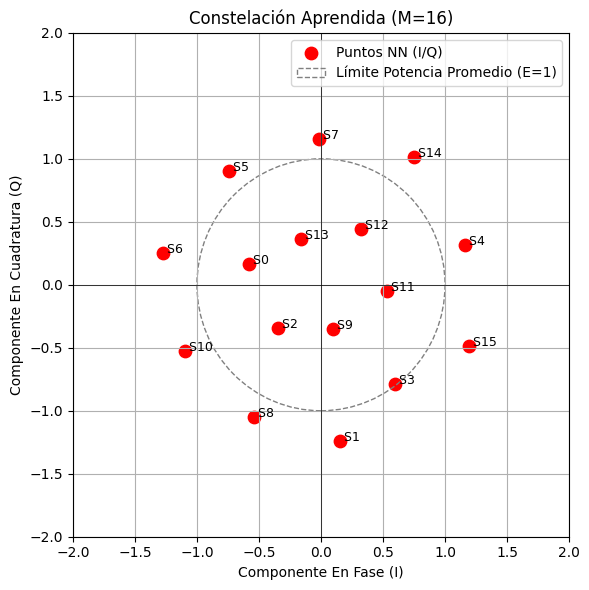

In [5]:
plot_learned_constellation(model, title="Constelación Aprendida (M=16)", save_path="../docs/constellation_learned.png")

[AWGN] Eb/N0 = 0 dB | BER = 0.296995
[AWGN] Eb/N0 = 2 dB | BER = 0.244059
[AWGN] Eb/N0 = 4 dB | BER = 0.187379
[AWGN] Eb/N0 = 6 dB | BER = 0.129086
[AWGN] Eb/N0 = 8 dB | BER = 0.074552
[AWGN] Eb/N0 = 10 dB | BER = 0.034820


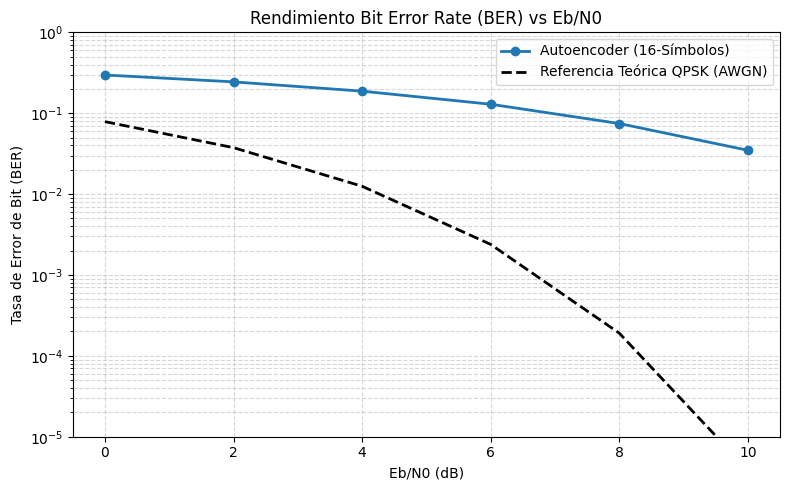

In [6]:
ebno_axis, ber_nn = evaluate_ber(model, channel_type="awgn", ebno_db_range=range(0, 12, 2))
ber_qpsk = theoretical_qpsk_ber(ebno_axis)
plot_ber_curves(ebno_axis, ber_nn, ber_qpsk, label="Autoencoder (16-Símbolos)", save_path="../docs/ber_performance_curve.png")